# 세팅하기

## 기본환경

In [177]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [178]:
# 한글 폰트 지정
import matplotlib.font_manager as fm

font_path = '/Users/mn/Desktop/finalproject/font_final/nanum-barun-gothic/NanumBarunGothic.ttf'  # 경로 확인 필요
fontprop = fm.FontProperties(fname=font_path)

plt.rc('font', family=fontprop.get_name())

In [179]:
print("폰트 이름:", fontprop.get_name())  # 꼭 확인

폰트 이름: NanumBarunGothic


In [180]:
# 컬럼 모두 출력
pd.set_option('display.max_columns', None)

In [181]:
# 현재 작업 디렉토리 출력
wd = os.getcwd()
wd

'/Users/mn/Desktop/finalproject/final_project_team3'

In [182]:
# 절대 경로 (수정해서 사용)
JSON_KEY_PATH = "/Users/mn/Desktop/finalproject/final_project_team3/key/my-projectcodeit.json"

## 테이블 불러오기

In [219]:
final_user_df = pd.read_parquet(
                                      "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/final_user_df.parquet",
                                      engine='pyarrow',
                                      storage_options={'token' : JSON_KEY_PATH})

In [220]:
final_user_df.head()

,created_at,user_id,gender,point,is_push_on,ban_status,report_count,alarm_count,friend_count,block_user_id_count,hide_user_id_count,attendance_count,pending_chat,pending_votes,address,student_count,school_grade,pointuse_cnt,pointget_cnt,vote_cnt,chosen_cnt,event_cnt,buy_cnt,buyfail_cnt,friendreport_cnt
0,2023-03-31 09:05:51.903699,833024,F,393,0,N,0,0,41,0,0,0,0,0,경기도 군포시,158.0,H_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2023-03-31 14:32:36.425315,833041,F,885000006,1,N,1,8,67,0,0,53,0,0,충청남도 천안시 동남구,131.0,H_3,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0
2,2023-03-31 15:55:48.870381,833112,M,290,1,N,0,1,13,0,0,3,0,0,충청남도 천안시 서북구,347.0,H_3,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0
3,2023-03-31 15:56:52.300066,833113,M,2801,1,N,0,3,23,0,0,0,0,49,충청남도 천안시 서북구,339.0,H_1,0.0,0.0,0.0,20.0,0.0,0.0,0.0,0.0
4,2023-03-31 15:57:39.008717,833154,F,5883,1,N,0,1,126,0,0,1,0,17,충청남도 천안시 서북구,339.0,H_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 이상치 제거

'vote_cnt'에 있는 2786 제거

In [221]:
final_user_df.drop(
    final_user_df[final_user_df['vote_cnt'] == 2786].index,
    inplace=True
)

'pending_chat'에 있는 음수값 제거

In [222]:
final_user_df.drop(
    final_user_df[final_user_df['pending_chat'] < 0].index,
    inplace=True
)

## 테이블 분리

- 활동 유저(active_users)
- 비활동 유저(inactive_users)

기준: attendance_count가 0이면 비활동유저, 0이 아니면 활동유저

In [223]:
# 활동 유저
active_users = final_user_df[final_user_df['attendance_count'] != 0]
active_users.head()

,created_at,user_id,gender,point,is_push_on,ban_status,report_count,alarm_count,friend_count,block_user_id_count,hide_user_id_count,attendance_count,pending_chat,pending_votes,address,student_count,school_grade,pointuse_cnt,pointget_cnt,vote_cnt,chosen_cnt,event_cnt,buy_cnt,buyfail_cnt,friendreport_cnt
1,2023-03-31 14:32:36.425315,833041,F,885000006,1,N,1,8,67,0,0,53,0,0,충청남도 천안시 동남구,131.0,H_3,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0
2,2023-03-31 15:55:48.870381,833112,M,290,1,N,0,1,13,0,0,3,0,0,충청남도 천안시 서북구,347.0,H_3,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0
4,2023-03-31 15:57:39.008717,833154,F,5883,1,N,0,1,126,0,0,1,0,17,충청남도 천안시 서북구,339.0,H_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,2023-03-31 15:58:12.136011,833202,F,337,1,N,0,1,103,0,3,2,0,2,충청남도 천안시 서북구,339.0,H_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,2023-03-31 15:58:14.619962,833203,M,2964,1,N,0,0,84,0,0,8,0,107,충청남도 천안시 서북구,339.0,H_1,0.0,0.0,0.0,116.0,0.0,0.0,0.0,0.0


In [224]:
active_users.shape

(328661, 25)

In [225]:
# 비활동 유저
inactive_users = final_user_df[final_user_df['attendance_count'] == 0]
inactive_users.head()

,created_at,user_id,gender,point,is_push_on,ban_status,report_count,alarm_count,friend_count,block_user_id_count,hide_user_id_count,attendance_count,pending_chat,pending_votes,address,student_count,school_grade,pointuse_cnt,pointget_cnt,vote_cnt,chosen_cnt,event_cnt,buy_cnt,buyfail_cnt,friendreport_cnt
0,2023-03-31 09:05:51.903699,833024,F,393,0,N,0,0,41,0,0,0,0,0,경기도 군포시,158.0,H_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2023-03-31 15:56:52.300066,833113,M,2801,1,N,0,3,23,0,0,0,0,49,충청남도 천안시 서북구,339.0,H_1,0.0,0.0,0.0,20.0,0.0,0.0,0.0,0.0
5,2023-03-31 15:58:10.987943,833201,F,3232,1,N,0,0,75,0,0,0,0,3,충청남도 천안시 서북구,339.0,H_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,2023-03-31 15:59:19.383659,833210,M,517,1,N,0,3,30,0,0,0,0,78,충청남도 천안시 서북구,347.0,H_2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12,2023-03-31 16:02:37.872802,833306,M,79,1,N,0,0,26,0,0,0,0,16,충청남도 천안시 서북구,347.0,H_3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [226]:
inactive_users.shape

(348320, 25)

In [262]:
inactive_users['pending_votes'].unique()

array([   0,   49,    3, ..., 1564, 1646, 1164], shape=(1096,))

In [227]:
inactive_users['Cluster_Name'] = "비활동 유저"

/var/folders/2v/mtvgzsyj7t904n0q0zp_35l80000gn/T/ipykernel_1265/1981400099.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inactive_users['Cluster_Name'] = "비활동 유저"


In [228]:
inactive_users.head()

,created_at,user_id,gender,point,is_push_on,ban_status,report_count,alarm_count,friend_count,block_user_id_count,hide_user_id_count,attendance_count,pending_chat,pending_votes,address,student_count,school_grade,pointuse_cnt,pointget_cnt,vote_cnt,chosen_cnt,event_cnt,buy_cnt,buyfail_cnt,friendreport_cnt,Cluster_Name
0,2023-03-31 09:05:51.903699,833024,F,393,0,N,0,0,41,0,0,0,0,0,경기도 군포시,158.0,H_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,비활동 유저
3,2023-03-31 15:56:52.300066,833113,M,2801,1,N,0,3,23,0,0,0,0,49,충청남도 천안시 서북구,339.0,H_1,0.0,0.0,0.0,20.0,0.0,0.0,0.0,0.0,비활동 유저
5,2023-03-31 15:58:10.987943,833201,F,3232,1,N,0,0,75,0,0,0,0,3,충청남도 천안시 서북구,339.0,H_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,비활동 유저
8,2023-03-31 15:59:19.383659,833210,M,517,1,N,0,3,30,0,0,0,0,78,충청남도 천안시 서북구,347.0,H_2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,비활동 유저
12,2023-03-31 16:02:37.872802,833306,M,79,1,N,0,0,26,0,0,0,0,16,충청남도 천안시 서북구,347.0,H_3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,비활동 유저


# active_users 가지고 클러스터링

In [229]:
data_cluster = active_users.copy()[['attendance_count', 
                                    'pending_chat', 'friend_count', 
                                    'vote_cnt', 'buy_cnt', 'chosen_cnt', 
                                    'pointuse_cnt', 'ban_status']]
data_cluster.head()

,attendance_count,pending_chat,friend_count,vote_cnt,buy_cnt,chosen_cnt,pointuse_cnt,ban_status
1,53,0,67,0.0,2.0,0.0,0.0,N
2,3,0,13,0.0,0.0,2.0,0.0,N
4,1,0,126,0.0,0.0,0.0,0.0,N
6,2,0,103,0.0,0.0,0.0,0.0,N
7,8,0,84,0.0,0.0,116.0,0.0,N


원 핫 인코딩

In [230]:
df_encoded = pd.get_dummies(data_cluster, columns=['ban_status'], drop_first=False)

로그 변환

In [231]:
df_log = np.log1p(df_encoded) 

In [232]:
ss = StandardScaler()
data_standardized = ss.fit_transform(df_log)

In [233]:
X = pd.DataFrame(data_standardized, columns=df_log.columns)
X

,attendance_count,pending_chat,friend_count,vote_cnt,buy_cnt,chosen_cnt,pointuse_cnt,ban_status_N,ban_status_NB,ban_status_RB,ban_status_W
0,2.829531,-0.24833,0.531181,-0.078392,3.061658,-0.123339,-0.075672,0.107025,-0.004273,-0.012335,-0.106208
1,-0.340492,-0.24833,-2.221542,-0.078392,-0.347967,2.098815,-0.075672,0.107025,-0.004273,-0.012335,-0.106208
2,-1.184731,-0.24833,1.619206,-0.078392,-0.347967,-0.123339,-0.075672,0.107025,-0.004273,-0.012335,-0.106208
3,-0.690883,-0.24833,1.271214,-0.078392,-0.347967,-0.123339,-0.075672,0.107025,-0.004273,-0.012335,-0.106208
4,0.647205,-0.24833,0.919837,-0.078392,-0.347967,9.509071,-0.075672,0.107025,-0.004273,-0.012335,-0.106208
...,...,...,...,...,...,...,...,...,...,...,...
328656,-1.184731,-0.24833,-1.600310,-0.078392,-0.347967,-0.123339,-0.075672,0.107025,-0.004273,-0.012335,-0.106208
328657,-1.184731,-0.24833,-4.403521,-0.078392,-0.347967,-0.123339,-0.075672,-9.343568,-0.004273,-0.012335,9.415472
328658,-1.184731,-0.24833,-2.101375,-0.078392,-0.347967,-0.123339,-0.075672,0.107025,-0.004273,-0.012335,-0.106208
328659,-1.184731,-0.24833,-6.818076,-0.078392,-0.347967,-0.123339,-0.075672,0.107025,-0.004273,-0.012335,-0.106208


## KMeans

findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Fo

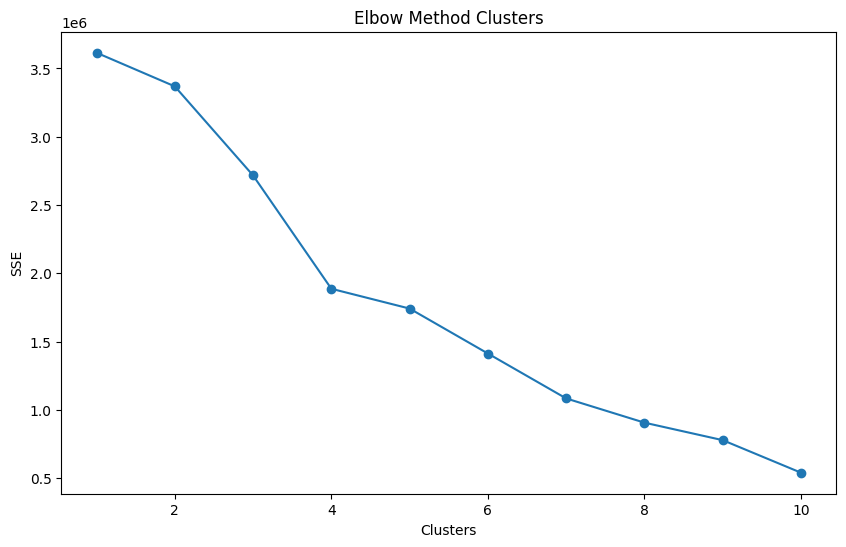

In [234]:
# Elbow Method를 사용한 클러스터 수 결정

sse = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=123)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)

# 시각화
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), sse, marker='o')
plt.title('Elbow Method Clusters')
plt.xlabel('Clusters')
plt.ylabel('SSE')
plt.show()

In [235]:
# k-means
kmeans = KMeans(n_clusters=4, random_state=123)
kmeans.fit(X)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,123
,copy_x,True
,algorithm,'lloyd'


In [236]:
df_kmeans = X.copy()

In [237]:
# 클러스터 결과 할당
df_kmeans['Kmeans_result'] = kmeans.predict(X)
# 클러스터 특성 분석
cluster_result = df_kmeans.groupby('Kmeans_result').mean()
cluster_result['COUNT'] = df_kmeans['Kmeans_result'].value_counts()
cluster_result.reset_index()

,Kmeans_result,attendance_count,pending_chat,friend_count,vote_cnt,buy_cnt,chosen_cnt,pointuse_cnt,ban_status_N,ban_status_NB,ban_status_RB,ban_status_W,COUNT
0,0,-0.688476,-0.072977,-0.107240,-0.076879,-0.208232,-0.056889,-0.075229,0.106722,0.003254,-0.012335,-0.106208,186560
1,1,-0.117467,0.028594,-0.389932,-0.074327,-0.078992,-0.073241,-0.073034,-9.343568,-0.004273,1.086033,9.286487,3691
2,2,0.946808,0.099831,0.154776,-0.077758,0.286637,-0.072965,-0.075515,0.107025,-0.004273,-0.012335,-0.106208,136397
3,3,-0.132246,-0.053481,0.166440,12.530007,0.021338,10.350644,12.222710,-0.010344,-0.004273,-0.012335,0.012044,2013


In [142]:
# 클러스터 라벨 
labels = kmeans.labels_

# 실루엣 점수 계산
score = silhouette_score(X, labels)
print(f'Silhouette Score: {score:.4f}')


Silhouette Score: 0.2656


### PCA

In [238]:
pca = PCA(n_components=3)
principal_components = pca.fit_transform(X)
pca_df = pd.DataFrame(principal_components, columns=['PC1', 'PC2', 'PC3'])
pca_df.head()

,PC1,PC2,PC3
0,-0.162207,0.297475,3.288941
1,1.018292,0.007025,-1.664361
2,-0.111799,0.217178,-0.004294
3,-0.124432,0.206685,0.051305
4,5.170022,0.230693,0.515714


In [239]:
print(pca.explained_variance_ratio_)

[0.24766845 0.18216573 0.103811  ]


findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Font family 'NanumBarunGothic' not found.
findfont: Fo

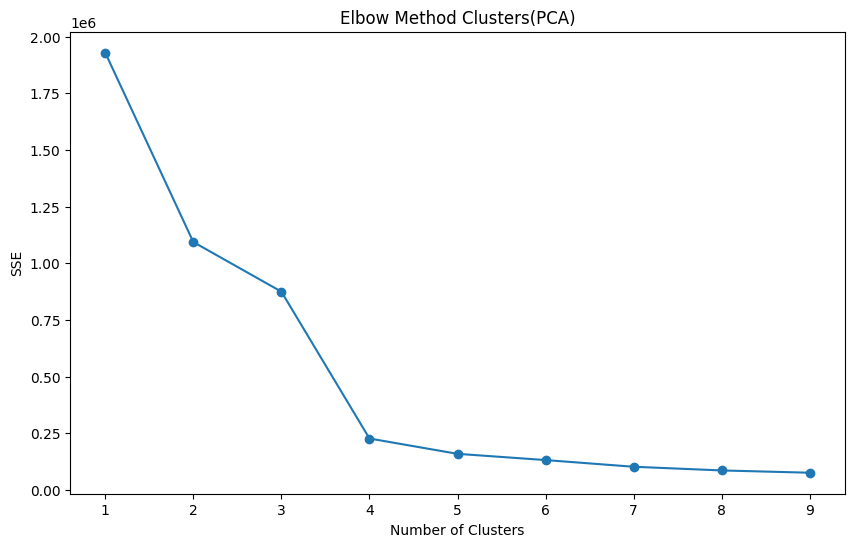

In [240]:
# Elbow Plot 시각화
from sklearn.cluster import KMeans

inertias = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=123)
    kmeans.fit(pca_df)
    inertias.append(kmeans.inertia_)

# 시각화
plt.figure(figsize=(10, 6))
plt.plot(range(1, 10), inertias, marker='o')
plt.title('Elbow Method Clusters(PCA)')
plt.xlabel('Number of Clusters')
plt.ylabel('SSE')
plt.show()

In [241]:
# k-means
pca_kmeans = KMeans(n_clusters=4, random_state=123)
pca_kmeans.fit(pca_df)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,123
,copy_x,True
,algorithm,'lloyd'


In [242]:
df_pca_kmeans = X.copy()

In [243]:
# 클러스터 결과 할당
df_pca_kmeans['Cluster'] = pca_kmeans.predict(pca_df)
# 클러스터 특성 분석
pca_cluster_result = df_pca_kmeans.groupby('Cluster').mean()
pca_cluster_result['COUNT'] = df_pca_kmeans['Cluster'].value_counts()
pca_cluster_result.reset_index()

,Cluster,attendance_count,pending_chat,friend_count,vote_cnt,buy_cnt,chosen_cnt,pointuse_cnt,ban_status_N,ban_status_NB,ban_status_RB,ban_status_W,COUNT
0,0,-0.316906,-0.211158,-0.259034,-0.076928,-0.308781,-0.067480,-0.075177,0.107025,-0.004273,-0.012335,-0.106208,221116
1,1,-0.132381,-0.053481,0.166918,12.528660,0.021338,10.355078,12.220010,-0.010344,-0.004273,-0.012335,0.012044,2013
2,2,0.695016,0.458526,0.573295,-0.077924,0.672924,-0.055509,-0.075672,0.107025,-0.004273,-0.012335,-0.106208,101835
3,3,-0.118342,0.028145,-0.389766,-0.074334,-0.079428,-0.073323,-0.073038,-9.343568,0.375570,1.084251,9.271243,3697


In [244]:
pca_labels = pca_kmeans.labels_

In [ ]:
# k-means(PCA)
silhouette_kmeans = silhouette_score(pca_df, df_pca_kmeans['Cluster'])
print(f'Silhouette Score (k-means_PCA): {silhouette_kmeans:.4f}')

Silhouette Score (k-means_PCA): 0.5504


## 클러스터링 라벨링

In [245]:
active_users['Cluster'] = pca_labels  

/var/folders/2v/mtvgzsyj7t904n0q0zp_35l80000gn/T/ipykernel_1265/592802561.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  active_users['Cluster'] = pca_labels


In [246]:
# 숫자형 데이터에 user_id 추가
final_cluster = data_cluster.copy()
final_cluster['user_id'] = active_users['user_id'].values
final_cluster['Cluster_label'] = pca_kmeans

# active_users와 병합
active_users = active_users.merge(
    final_cluster[['user_id','Cluster_label']],
    on='user_id',
    how='left'
)
active_users.head()

,created_at,user_id,gender,point,is_push_on,ban_status,report_count,alarm_count,friend_count,block_user_id_count,hide_user_id_count,attendance_count,pending_chat,pending_votes,address,student_count,school_grade,pointuse_cnt,pointget_cnt,vote_cnt,chosen_cnt,event_cnt,buy_cnt,buyfail_cnt,friendreport_cnt,Cluster,Cluster_label
0,2023-03-31 14:32:36.425315,833041,F,885000006,1,N,1,8,67,0,0,53,0,0,충청남도 천안시 동남구,131.0,H_3,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,2,"KMeans(n_clusters=4, random_state=123)"
1,2023-03-31 15:55:48.870381,833112,M,290,1,N,0,1,13,0,0,3,0,0,충청남도 천안시 서북구,347.0,H_3,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0,"KMeans(n_clusters=4, random_state=123)"
2,2023-03-31 15:57:39.008717,833154,F,5883,1,N,0,1,126,0,0,1,0,17,충청남도 천안시 서북구,339.0,H_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,"KMeans(n_clusters=4, random_state=123)"
3,2023-03-31 15:58:12.136011,833202,F,337,1,N,0,1,103,0,3,2,0,2,충청남도 천안시 서북구,339.0,H_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,"KMeans(n_clusters=4, random_state=123)"
4,2023-03-31 15:58:14.619962,833203,M,2964,1,N,0,0,84,0,0,8,0,107,충청남도 천안시 서북구,339.0,H_1,0.0,0.0,0.0,116.0,0.0,0.0,0.0,0.0,2,"KMeans(n_clusters=4, random_state=123)"


In [247]:
active_users = active_users.drop(columns=['Cluster_label'], errors='ignore')

In [248]:
cluster_names = {
    0: "휴면 유저",
    1: "슈퍼 유저",
    2: "소셜 유저",
    3: "관리 대상 유저"
}

active_users["Cluster_Name"] = active_users["Cluster"].map(cluster_names)
active_users.head()

,created_at,user_id,gender,point,is_push_on,ban_status,report_count,alarm_count,friend_count,block_user_id_count,hide_user_id_count,attendance_count,pending_chat,pending_votes,address,student_count,school_grade,pointuse_cnt,pointget_cnt,vote_cnt,chosen_cnt,event_cnt,buy_cnt,buyfail_cnt,friendreport_cnt,Cluster,Cluster_Name
0,2023-03-31 14:32:36.425315,833041,F,885000006,1,N,1,8,67,0,0,53,0,0,충청남도 천안시 동남구,131.0,H_3,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,2,소셜 유저
1,2023-03-31 15:55:48.870381,833112,M,290,1,N,0,1,13,0,0,3,0,0,충청남도 천안시 서북구,347.0,H_3,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0,휴면 유저
2,2023-03-31 15:57:39.008717,833154,F,5883,1,N,0,1,126,0,0,1,0,17,충청남도 천안시 서북구,339.0,H_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,휴면 유저
3,2023-03-31 15:58:12.136011,833202,F,337,1,N,0,1,103,0,3,2,0,2,충청남도 천안시 서북구,339.0,H_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,휴면 유저
4,2023-03-31 15:58:14.619962,833203,M,2964,1,N,0,0,84,0,0,8,0,107,충청남도 천안시 서북구,339.0,H_1,0.0,0.0,0.0,116.0,0.0,0.0,0.0,0.0,2,소셜 유저


In [249]:
active_users['Cluster'].unique()

array([2, 0, 3, 1], dtype=int32)

In [250]:
active_users['Cluster_Name'].unique()

array(['소셜 유저', '휴면 유저', '관리 대상 유저', '슈퍼 유저'], dtype=object)

In [251]:
active_users

,created_at,user_id,gender,point,is_push_on,ban_status,report_count,alarm_count,friend_count,block_user_id_count,hide_user_id_count,attendance_count,pending_chat,pending_votes,address,student_count,school_grade,pointuse_cnt,pointget_cnt,vote_cnt,chosen_cnt,event_cnt,buy_cnt,buyfail_cnt,friendreport_cnt,Cluster,Cluster_Name
0,2023-03-31 14:32:36.425315,833041,F,885000006,1,N,1,8,67,0,0,53,0,0,충청남도 천안시 동남구,131.0,H_3,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,2,소셜 유저
1,2023-03-31 15:55:48.870381,833112,M,290,1,N,0,1,13,0,0,3,0,0,충청남도 천안시 서북구,347.0,H_3,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0,휴면 유저
2,2023-03-31 15:57:39.008717,833154,F,5883,1,N,0,1,126,0,0,1,0,17,충청남도 천안시 서북구,339.0,H_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,휴면 유저
3,2023-03-31 15:58:12.136011,833202,F,337,1,N,0,1,103,0,3,2,0,2,충청남도 천안시 서북구,339.0,H_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,휴면 유저
4,2023-03-31 15:58:14.619962,833203,M,2964,1,N,0,0,84,0,0,8,0,107,충청남도 천안시 서북구,339.0,H_1,0.0,0.0,0.0,116.0,0.0,0.0,0.0,0.0,2,소셜 유저
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328656,2024-05-05 00:31:30.745794,1583708,F,363,1,N,0,0,19,0,0,1,0,0,대전광역시 서구,261.0,M_2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,휴면 유저
328657,2024-05-05 04:46:21.254737,1583710,M,350,0,W,0,1,3,0,0,1,0,0,서울특별시 은평구,292.0,H_2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,관리 대상 유저
328658,2024-05-05 12:16:29.392522,1583715,F,355,1,N,0,0,14,0,0,1,0,0,충청남도 홍성군,106.0,H_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,휴면 유저
328659,2024-05-07 11:57:29.459197,1583727,F,350,1,N,0,0,0,0,0,1,0,0,경기도 안산시 단원구,28.0,H_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,휴면 유저


In [252]:
fin_cluster_df = pd.concat([active_users, inactive_users], axis=0, ignore_index=True)

In [253]:
fin_cluster_df.head()

,created_at,user_id,gender,point,is_push_on,ban_status,report_count,alarm_count,friend_count,block_user_id_count,hide_user_id_count,attendance_count,pending_chat,pending_votes,address,student_count,school_grade,pointuse_cnt,pointget_cnt,vote_cnt,chosen_cnt,event_cnt,buy_cnt,buyfail_cnt,friendreport_cnt,Cluster,Cluster_Name
0,2023-03-31 14:32:36.425315,833041,F,885000006,1,N,1,8,67,0,0,53,0,0,충청남도 천안시 동남구,131.0,H_3,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,2.0,소셜 유저
1,2023-03-31 15:55:48.870381,833112,M,290,1,N,0,1,13,0,0,3,0,0,충청남도 천안시 서북구,347.0,H_3,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,휴면 유저
2,2023-03-31 15:57:39.008717,833154,F,5883,1,N,0,1,126,0,0,1,0,17,충청남도 천안시 서북구,339.0,H_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,휴면 유저
3,2023-03-31 15:58:12.136011,833202,F,337,1,N,0,1,103,0,3,2,0,2,충청남도 천안시 서북구,339.0,H_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,휴면 유저
4,2023-03-31 15:58:14.619962,833203,M,2964,1,N,0,0,84,0,0,8,0,107,충청남도 천안시 서북구,339.0,H_1,0.0,0.0,0.0,116.0,0.0,0.0,0.0,0.0,2.0,소셜 유저


In [255]:
fin_cluster_df['Cluster_Name'].unique()

array(['소셜 유저', '휴면 유저', '관리 대상 유저', '슈퍼 유저', '비활동 유저'], dtype=object)

### 빅쿼리로 보내기

In [256]:
import pandas as pd
from google.oauth2 import service_account

JSON_KEY_PATH = '/Users/mn/Desktop/finalproject/final_project_team3/key/my-projectcodeit.json'
PROJECT_ID = 'my-projectcodeit'
LOCATION = 'asia-northeast3'

# 서비스 계정 키 파일을 사용하여 인증 객체 생성
credentials = service_account.Credentials.from_service_account_file(JSON_KEY_PATH)

In [260]:
fin_cluster_df.to_gbq(
    destination_table="final_project.fin_cluster_df",
    project_id=PROJECT_ID,
    location=LOCATION,
    if_exists='replace',
    credentials=credentials
)

/var/folders/2v/mtvgzsyj7t904n0q0zp_35l80000gn/T/ipykernel_1265/1712513113.py:1: FutureWarning: to_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.to_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.to_gbq
  fin_cluster_df.to_gbq(
